### Ablation experiments: net value comparison across different portfolio model families (Original, –H, –P, –HP).

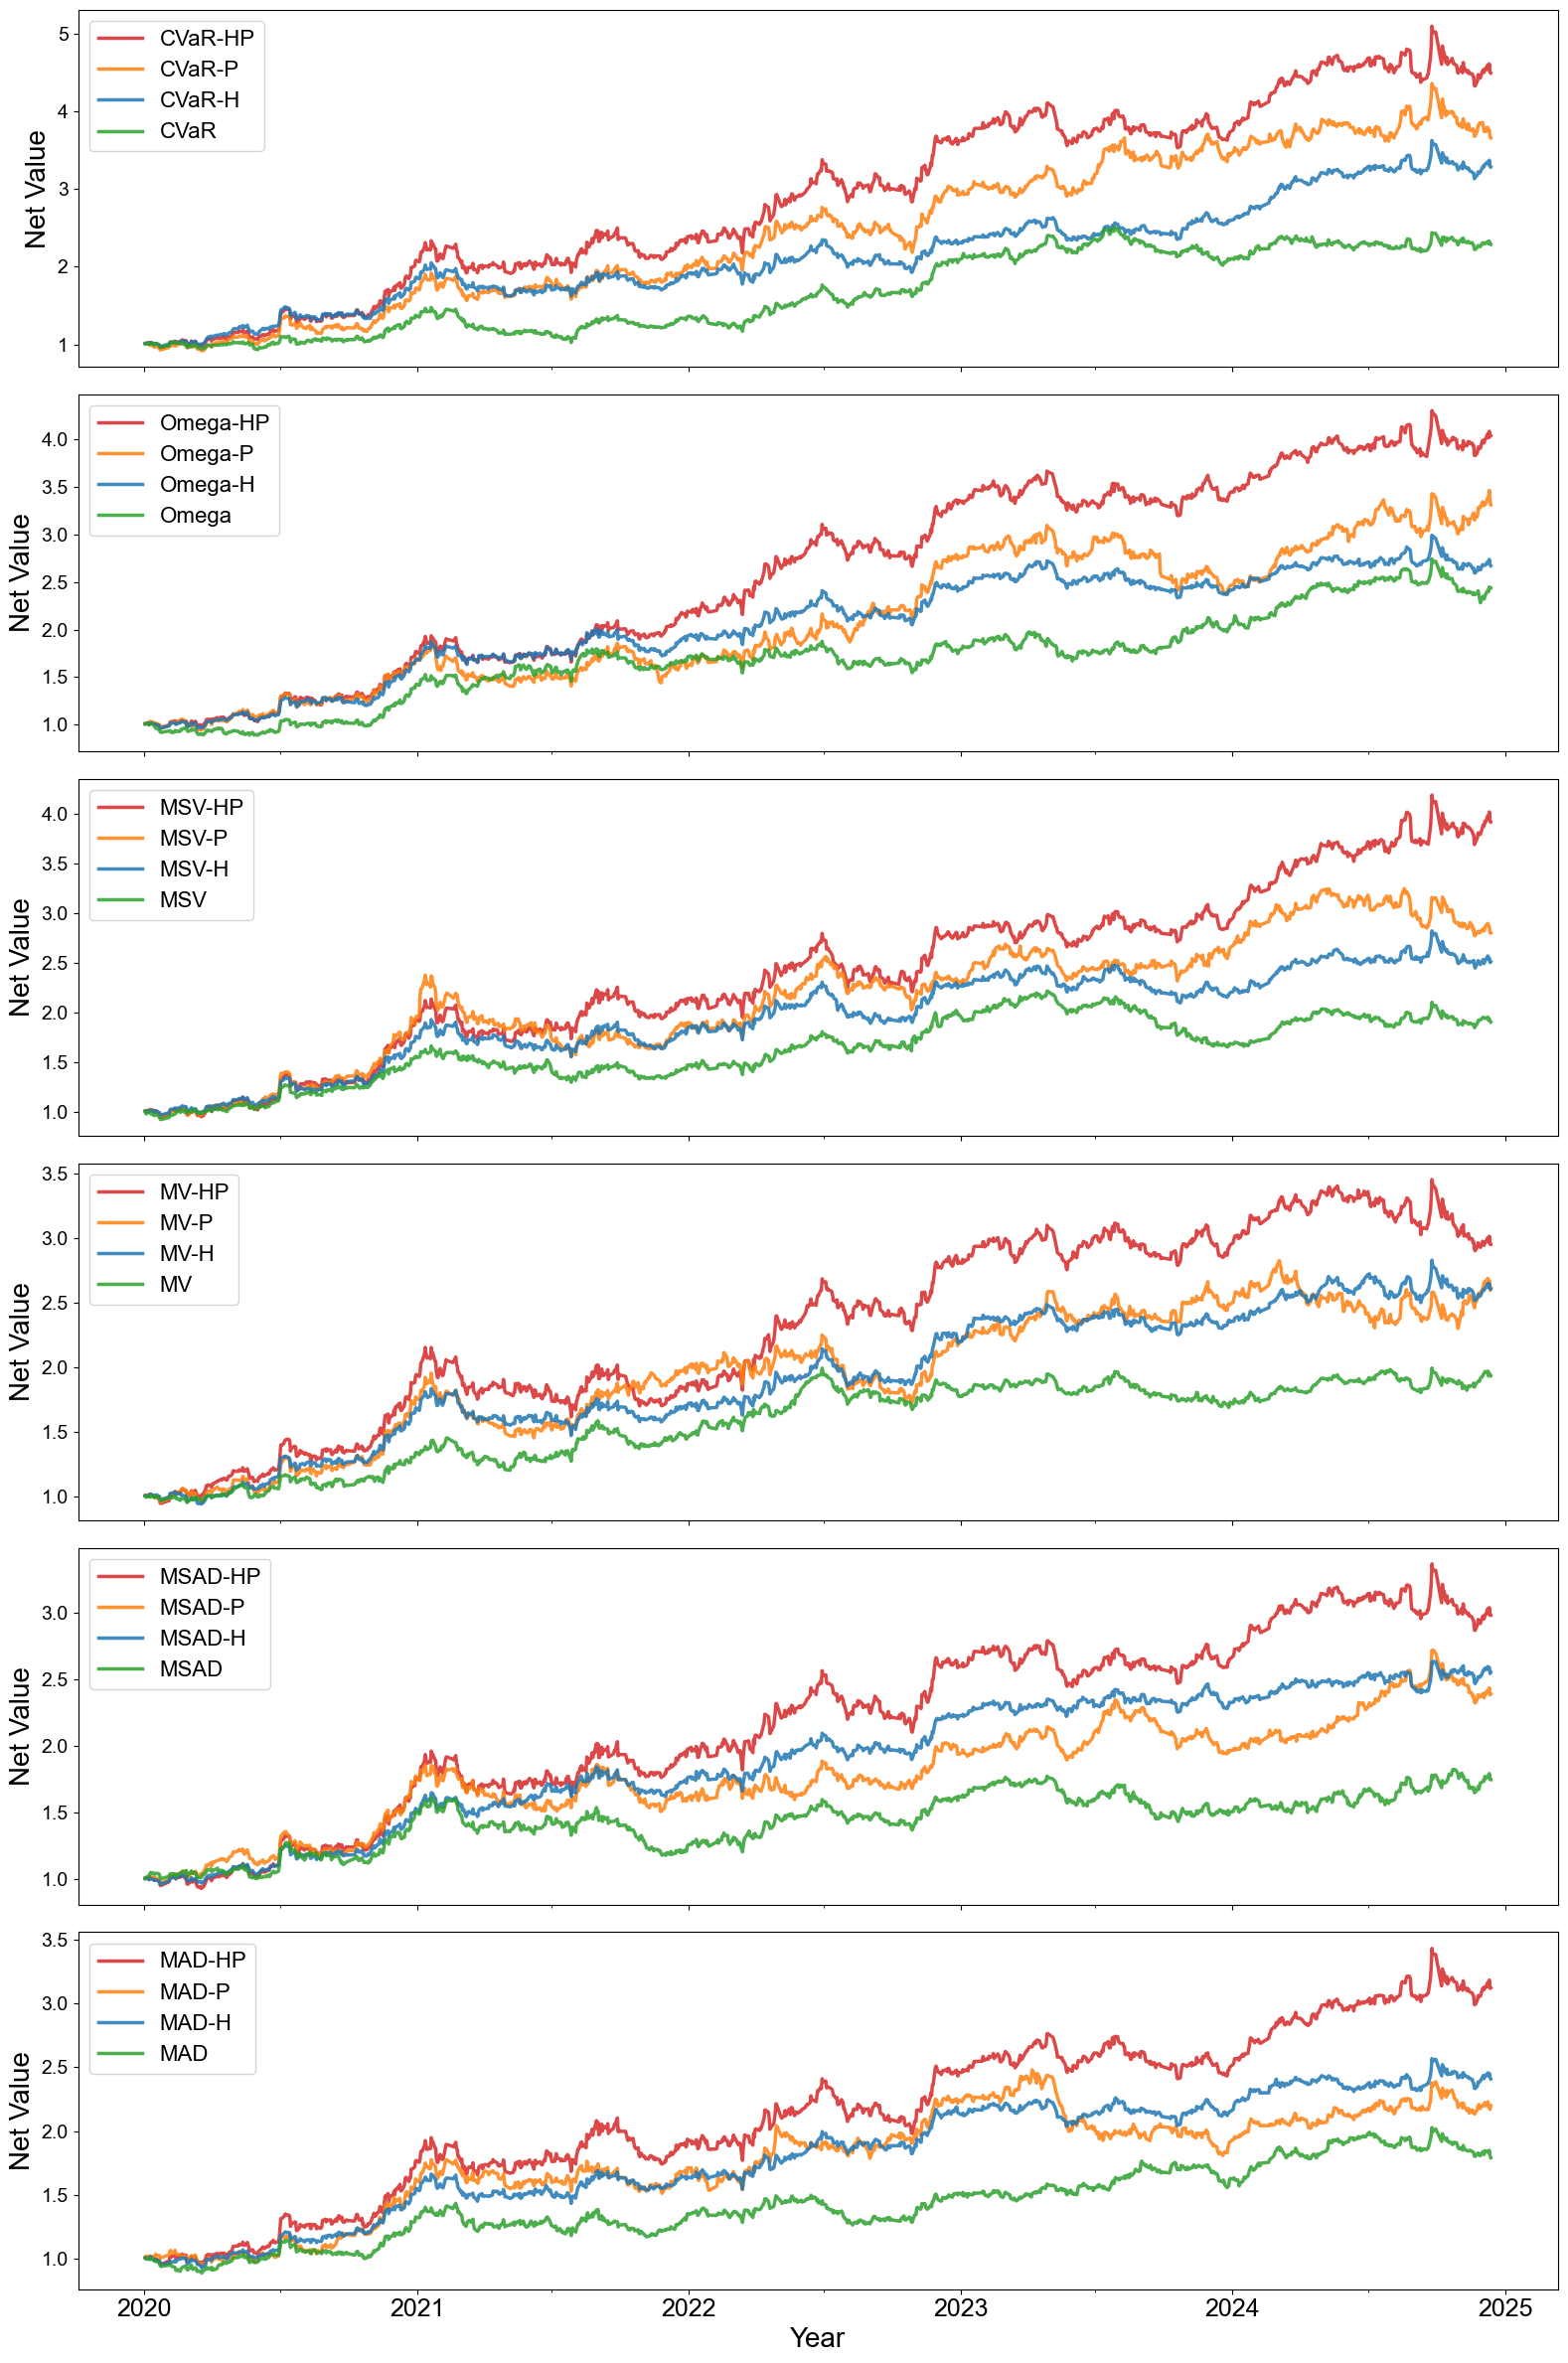

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.sans-serif'] = ['Arial']

def read_model_data(model_name):
    filename = f'portfolio_daily_returns.csv'
    df = pd.read_csv(filename)
    
    # 将date列转换为日期格式
    df['date'] = pd.to_datetime(df['date'])

    model_data = {
        'Original_return': df[model_name +'_Original'],
        'HigherMoments_return': df[model_name +'_HigherMoments'],
        'Predictive_return': df[model_name +'_Predictive'],
        'Integrated_return': df[model_name +'_Integrated']
    }

    return df['date'], model_data

def plot_all_models_subplot(all_dates, all_model_data, models_list):
    """
    绘制所有模型的组图,竖着排列
    """
    plt.rcParams.update({'font.size': 14})
    fig, axes = plt.subplots(6, 1, figsize=(16, 24))

    colors = {
        'Original': '#2ca02c',      # 原始绿色
        'HigherMoments': '#1f77b4', # -H蓝色
        'Predictive': '#ff7f0e',    # -P橘色
        'Integrated': '#d62728'     # -HP红色
    }
    
    for i, model_name in enumerate(models_list):
        ax = axes[i]
        dates = all_dates[model_name]
        model_data = all_model_data[model_name]

        original_cumret = (1 + model_data['Original_return']).cumprod()
        higher_cumret = (1 + model_data['HigherMoments_return']).cumprod()
        predictive_cumret = (1 + model_data['Predictive_return']).cumprod()
        integrated_cumret = (1 + model_data['Integrated_return']).cumprod()

        ax.plot(dates, integrated_cumret, 
                label=f'{model_name}-HP', 
                linewidth=2.5, alpha=0.85, color=colors['Integrated'])
        ax.plot(dates, predictive_cumret, 
                label=f'{model_name}-P', 
                linewidth=2.5, alpha=0.85, color=colors['Predictive'])
        ax.plot(dates, higher_cumret, 
                label=f'{model_name}-H', 
                linewidth=2.5, alpha=0.85, color=colors['HigherMoments'])
        ax.plot(dates, original_cumret, 
                label=f'{model_name}', 
                linewidth=2.5, alpha=0.85, color=colors['Original'])

        ax.set_ylabel('Net Value', fontsize=20)
        ax.legend(loc='best', fontsize=16)
        ax.grid(False)

        ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))

        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)

        if i == len(models_list) - 1:
            ax.set_xlabel('Year', fontsize=20)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=18)
        else:
            ax.xaxis.set_major_formatter(mdates.DateFormatter(''))
            plt.setp(ax.xaxis.get_majorticklabels(), visible=False)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 定义六个模型列表
    models_list = ['CVaR', 'Omega', 'MSV', 'MV', 'MSAD', 'MAD']
    all_model_data = {}
    all_dates = {}
    
    # 读取每个模型的数据
    for model_name in models_list:
        dates, model_data = read_model_data(model_name)
        all_dates[model_name] = dates
        all_model_data[model_name] = model_data
    plot_all_models_subplot(all_dates, all_model_data, models_list)

### Net value differences between the proposed –HP extensions and their original counterparts.

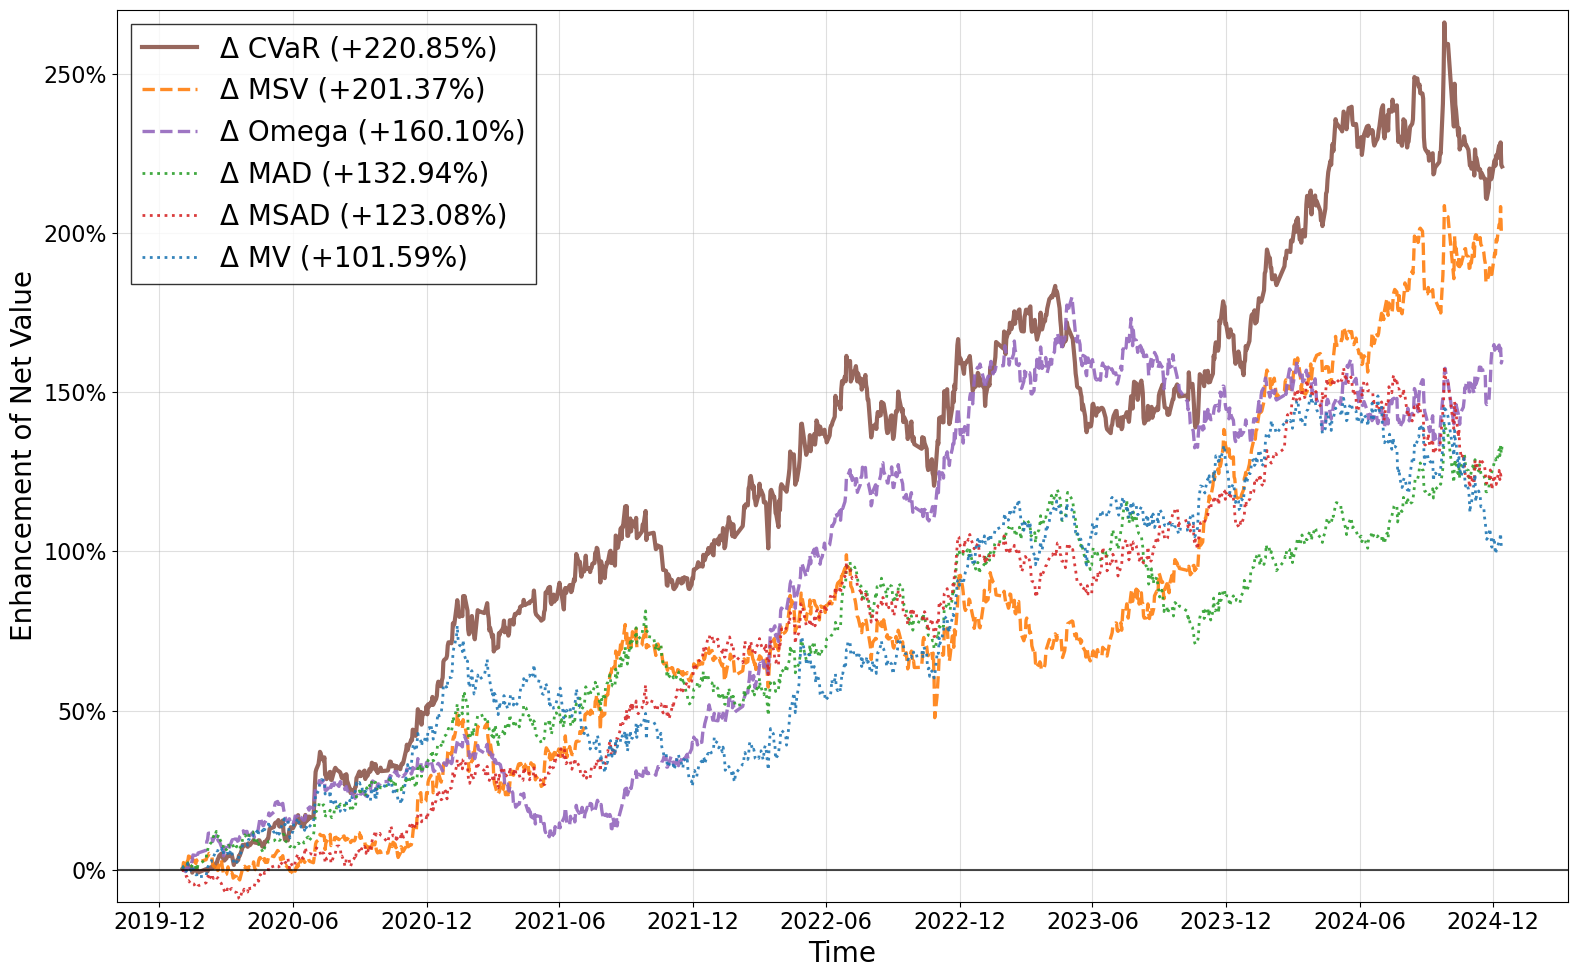

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

def plot_integrated_original_difference():
    """
    绘制六个模型的Integrated累计收益率减去Original累计收益率的差值图
    """
    plt.rcParams.update({'font.size': 14})
    df = pd.read_csv('portfolio_daily_returns.csv')
    df['date'] = pd.to_datetime(df['date'])
    
    # 定义六个模型
    models = ['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    
    # 首先计算所有模型的最终差值，用于排序
    model_final_diffs = []
    
    for model in models:
        integrated_col = f'{model}_Integrated'
        original_col = f'{model}_Original'
        
        # 检查列是否存在
        if integrated_col in df.columns and original_col in df.columns:
            # 计算累计收益率
            integrated_cumret = (1 + df[integrated_col]).cumprod() - 1
            original_cumret = (1 + df[original_col]).cumprod() - 1
            
            # 计算差值
            difference = integrated_cumret - original_cumret
            final_diff = difference.iloc[-1]
            
            model_final_diffs.append({
                'model': model,
                'final_diff': final_diff,
                'difference_series': difference
            })
    
    # 按最终差值从高到低排序
    model_final_diffs.sort(key=lambda x: x['final_diff'], reverse=True)
    
    # 设置图形
    plt.figure(figsize=(16, 10))
    
    # 定义指定的颜色映射
    model_colors = {
        'CVaR': '#8c564b',
        'Omega': '#9467bd', 
        'MSV': '#ff7f0e',
        'MAD': '#2ca02c',
        'MSAD': '#d62728',
        'MV': '#1f77b4'
    }

    line_styles = ['-', '--', '--', ':', ':', ':']
    line_widths = [3.0, 2.4, 2.4, 2.0, 2.0, 2.0]

    for i, model_data in enumerate(model_final_diffs):
        model = model_data['model']
        difference = model_data['difference_series']
        final_diff = model_data['final_diff']

        plt.plot(df['date'], difference, 
                label=f'Δ {model} (+{final_diff*100:.2f}%)', 
                color=model_colors[model], 
                linewidth=line_widths[i], 
                linestyle=line_styles[i],
                alpha=0.9
                )

    plt.axhline(y=0, color='black', linestyle='-', alpha=0.7, linewidth=1.5)
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Enhancement of Net Value', fontsize=20)
    plt.legend(loc='upper left', fontsize=20, frameon=True, 
              fancybox=False, shadow=False, edgecolor='black')
    plt.grid(True, alpha=0.4, linestyle='-', linewidth=0.8)
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[6, 12]))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.tick_params(axis='x', labelsize=16, rotation=0)
    plt.tick_params(axis='y', labelsize=16)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    plt.ylim(-0.1, 2.7)
    plt.tight_layout()
    plt.savefig('Integrated_vs_Original_Difference.png', dpi=300, bbox_inches='tight')
    plt.show()
    
if __name__ == "__main__":
    plot_integrated_original_difference()

### Statistical summary of all PO models.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

def calculate_portfolio_metrics_with_cost():
    """
    CR: 累计收益率 (Cumulative Return)
    ER: 超额收益率 (Excess Return) - 按照公式 ER = Σ(Rp,t - Rm,t) / T
    SD: 标准差 (Standard Deviation) - 基于月度超额收益率
    MD: 最大回撤 (Maximum Drawdown)
    IR: 信息比率 (Information Ratio) - ER / SD
    VaR: 风险价值 (Value at Risk) - 5%置信水平下的日度VaR
    CVaR: 条件风险价值 (Conditional Value at Risk) - 5%置信水平下的日度CVaR
    TUR: 平均换手率 (Turnover Rate) - 换手率的非零非第一个数据的平均值
    """
    df = pd.read_csv('portfolio_daily_returns.csv')
    df['date'] = pd.to_datetime(df['date'])
    turnover_df = pd.read_csv('portfolio_turnover_transformed.csv')
    turnover_df['date'] = pd.to_datetime(turnover_df['date'])
    
    benchmark_df = pd.read_csv('CSI141每日收益率_2020_2024.csv')
    benchmark_df['date'] = pd.to_datetime(benchmark_df['Date'])

    merged_df = pd.merge(df, benchmark_df, on='date', how='inner')
    merged_df = pd.merge(merged_df, turnover_df, on='date', how='inner')

    model_names = ['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    versions = ['Original', 'HigherMoments', 'Predictive', 'Integrated']
    
    # 步骤1: 收集投资组合列信息
    portfolio_columns = []
    turnover_columns = []
    
    for model_name in model_names:
        for version in versions:
            col_name = f'{model_name}_{version}'
            full_name = f'{model_name}-{version}'

            if version == 'Original':
                full_name = model_name  # Original版本不显示后缀
            elif version == 'HigherMoments':
                full_name = f'{model_name}-H'
            elif version == 'Predictive':
                full_name = f'{model_name}-P'
            elif version == 'Integrated':
                full_name = f'{model_name}-HP'
            
            if col_name in merged_df.columns:
                portfolio_columns.append((full_name, col_name))

            turnover_col_name = f'{model_name}_{version}_turnover'
            if turnover_col_name in merged_df.columns:
                turnover_columns.append((full_name, turnover_col_name))
    
    # 步骤2: 计算月度超额收益率
    merged_df['year_month'] = merged_df['date'].dt.to_period('M')
    
    # 先计算基准的月度收益率
    benchmark_monthly = merged_df.groupby('year_month')['CSI141_DailyReturn'].apply(
        lambda x: (1 + x).prod() - 1, include_groups=False
    )
    
    # 按月分组计算月度超额收益率
    monthly_excess_returns = {}
    monthly_data_list = []
    
    for full_name, col_name in portfolio_columns:
        # 先分别计算投资组合月度收益率
        portfolio_monthly = merged_df.groupby('year_month')[col_name].apply(
            lambda x: (1 + x).prod() - 1, include_groups=False
        )
        
        # 计算月度超额收益率: 投资组合月度收益率 - 基准月度收益率
        monthly_excess_values = portfolio_monthly - benchmark_monthly
        
        monthly_excess = pd.DataFrame({
            'year_month': monthly_excess_values.index,
            f'{full_name}_monthly_excess': monthly_excess_values.values
        }).reset_index(drop=True)
        
        if len(monthly_data_list) == 0:
            monthly_data_list.append(monthly_excess[['year_month', f'{full_name}_monthly_excess']])
        else:
            monthly_data_list.append(monthly_excess[[f'{full_name}_monthly_excess']])
        
        monthly_excess_returns[full_name] = monthly_excess_values

    if monthly_data_list:
        monthly_df = pd.concat(monthly_data_list, axis=1)
        monthly_df['year_month'] = monthly_df['year_month'].astype(str)
        monthly_df.to_csv('Monthly_Excess_Returns.csv', index=False, encoding='utf-8-sig')
        print("已保存: Monthly_Excess_Returns.csv")
    
    # 步骤3: 计算年度指标
    all_combinations = [full_name for full_name, _ in portfolio_columns]
    
    results = pd.DataFrame(
        index=all_combinations,
        columns=['CR', 'MD', 'ER', 'SD', 'IR', 'VaR', 'CVaR', 'TUR']
    )
    
    for full_name, col_name in portfolio_columns:
        portfolio_returns = merged_df[col_name]
        
        if full_name in monthly_excess_returns:
            monthly_excess = monthly_excess_returns[full_name]
        else:
            continue
        
        # 1. CR: 累计收益率 (Cumulative Return)
        cumulative_return = (1 + portfolio_returns).cumprod().iloc[-1] - 1
        
        # 2. ER: 超额收益率 - 按照公式 ER = Σ(Rp,t - Rm,t) / T
        ER = monthly_excess.mean()
        
        # 3. SD: 标准差 - 基于月度超额收益率的标准差
        SD = monthly_excess.std()
        
        # 4. IR: 信息比率 (Information Ratio) - ER / SD
        if SD != 0:
            IR = ER / SD
        else:
            IR = 0
        
        # 5. VaR(5%): 风险价值 - 基于日度收益率
        VaR = np.percentile(portfolio_returns, 5)
        
        # 6. CVaR(5%): 条件风险价值 - 基于日度收益率
        var_threshold = VaR
        tail_returns = portfolio_returns[portfolio_returns <= var_threshold]
        if len(tail_returns) > 0:
            CVaR = tail_returns.mean()
        else:
            CVaR = VaR
        
        # 7. MD: 最大回撤 (Maximum Drawdown)
        cumulative_returns = (1 + portfolio_returns).cumprod()
        peak = cumulative_returns.expanding().max()
        drawdown = (cumulative_returns - peak) / peak
        max_drawdown = drawdown.min()
        
        # 8. TUR: 平均换手率 (Turnover Rate)
        TUR = 0
        turnover_col_name = f'{col_name}_turnover'
        if turnover_col_name in merged_df.columns:
            turnover_data = merged_df[turnover_col_name].values
            
            mask = np.ones(len(turnover_data), dtype=bool)
            mask[0] = False  # 排除第一个数据点
            mask = mask & (turnover_data != 0)  # 排除零值
            
            # 计算非零非第一个数据的平均值
            if mask.sum() > 0:
                TUR = turnover_data[mask].mean()
            else:
                TUR = 0
        
        results.loc[full_name, 'CR'] = f"{cumulative_return:.6f}"
        results.loc[full_name, 'MD'] = f"{max_drawdown:.6f}"
        results.loc[full_name, 'ER'] = f"{ER:.6f}"
        results.loc[full_name, 'SD'] = f"{SD:.6f}"
        results.loc[full_name, 'IR'] = f"{IR:.6f}"
        results.loc[full_name, 'VaR'] = f"{VaR:.8f}"
        results.loc[full_name, 'CVaR'] = f"{CVaR:.8f}"
        results.loc[full_name, 'TUR'] = f"{TUR:.4f}"
    
    return results, monthly_df

def display_and_save_results_with_cost():
    """
    显示和保存包含成本比率和风险指标的结果
    """

    results_df, monthly_df = calculate_portfolio_metrics_with_cost()

    model_names = ['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    version_order = ['', '-H', '-P', '-HP']

    print("\n" + "=" * 110)
    print("Portfolio Performance Metrics")
    print("=" * 110)
    
    for model_name in model_names:
        print(f"\n{model_name} 模型:")
        print("-" * 100)
        
        for version_suffix in version_order:
            if version_suffix == '':
                full_name = model_name
            else:
                full_name = f'{model_name}{version_suffix}'
                
            if full_name in results_df.index:
                row_data = results_df.loc[full_name]
                print(f"{full_name:<10} CR={row_data['CR']:<8} MD={row_data['MD']:<8} ER={row_data['ER']:<8} SD={row_data['SD']:<8} "
                      f"IR={row_data['IR']:<8} VaR={row_data['VaR']:<8} CVaR={row_data['CVaR']:<8} "
                       f"TUR={row_data['TUR']:<8}")

    print("\n" + "=" * 110)

    results_df.to_csv('Portfolio_Metrics_Results_WithRisk.csv', encoding='utf-8-sig')

    return results_df
if __name__ == "__main__":
    results = display_and_save_results_with_cost()


已保存: Monthly_Excess_Returns.csv

Portfolio Performance Metrics

MV 模型:
----------------------------------------------------------------------------------------------------
MV         CR=0.936594 MD=-0.172283 ER=0.006552 SD=0.051039 IR=0.128372 VaR=-0.01686936 CVaR=-0.02387454 TUR=0.2495  
MV-H       CR=1.608083 MD=-0.197648 ER=0.011786 SD=0.048716 IR=0.241940 VaR=-0.01716453 CVaR=-0.02603059 TUR=0.2649  
MV-P       CR=1.614824 MD=-0.255819 ER=0.012413 SD=0.059771 IR=0.207680 VaR=-0.02179441 CVaR=-0.03209265 TUR=0.3051  
MV-HP      CR=1.952513 MD=-0.249114 ER=0.014622 SD=0.060476 IR=0.241777 VaR=-0.02149964 CVaR=-0.03160478 TUR=0.3743  

MSV 模型:
----------------------------------------------------------------------------------------------------
MSV        CR=0.906651 MD=-0.253096 ER=0.006382 SD=0.049754 IR=0.128262 VaR=-0.01871980 CVaR=-0.02746914 TUR=0.2615  
MSV-H      CR=1.514899 MD=-0.193803 ER=0.011464 SD=0.051936 IR=0.220743 VaR=-0.01864348 CVaR=-0.02823678 TUR=0.2782  
MSV-P     

### Newey-West test to determine whether the proposed models' returns significantly exceed the risk-free rate.

In [8]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

def newey_west_test(returns, lags=None, risk_free_rate=0.03/365):
    """
    对收益率序列进行Newey-West检验（检验超额收益率均值是否显著不为0）
    """
    if lags is None:
        T = len(returns)
        lags = int(4 * (T/100)**(2/9)) 
    
    # 计算超额收益率
    excess_returns = returns - risk_free_rate
    
    # 准备数据进行回归
    y = excess_returns.values
    X = np.ones((len(y), 1))
    
    # 使用statsmodels进行回归并计算Newey-West标准误
    model = OLS(y, X)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    
    # 提取系数、标准误、t统计量和p值
    coef = results.params[0]
    std_err = results.bse[0]
    t_stat = results.tvalues[0]
    p_value = results.pvalues[0]
    
    return {
        'coefficient': coef,
        'std_error': std_err,
        't_statistic': t_stat,
        'p_value': p_value
    }


def create_newey_west_table():
    """
    创建Newey-West检验表格
    """
    df = pd.read_csv('portfolio_daily_returns.csv')
    df['date'] = pd.to_datetime(df['date'])

    
    # 提取Integrated模型（HP）的数据
    integrated_models = {}
    model_names = ['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    
    for model_name in model_names:
        col_name = f'{model_name}_Integrated'
        integrated_models[f'{model_name}-HP'] = df[col_name]


    
    # Newey-West Test
    print("=" * 60)
    print("Newey-West Test Results")
    print("=" * 60)
    
    nw_results = []
    
    for model_name, returns in integrated_models.items():
        nw_result = newey_west_test(returns)
        
        # 收益率
        return_with_sig = f"{nw_result['coefficient']:.6f}"
        
        # T值
        t_value_str = f"{nw_result['t_statistic']:.4f}"
        
        # p值
        p_value_str = f"{nw_result['p_value']:.4f}"
        
        nw_results.append({
            'Model': model_name,
            'Return': f"{returns.mean():.6f}",
            'SD': f"{returns.std():.6f}",
            'Skew': f"{stats.skew(returns):.4f}",
            'Kurt': f"{stats.kurtosis(returns, fisher=True):.4f}",
            'Excess Return': return_with_sig,
            'T-value': t_value_str,
            'P-value': p_value_str
        })
    
    nw_df = pd.DataFrame(nw_results)
    print(nw_df.to_string(index=False))

    nw_df.to_csv('Newey_West_Results.csv', index=False, encoding='utf-8-sig')

# 运行分析
if __name__ == "__main__":
    result = create_newey_west_table()

Newey-West Test Results
   Model   Return       SD   Skew   Kurt Excess Return T-value P-value
   MV-HP 0.001004 0.014279 0.0992 2.9015      0.000922  2.3592  0.0183
  MSV-HP 0.001266 0.015959 0.0620 3.2567      0.001184  2.7582  0.0058
  MAD-HP 0.001046 0.014005 0.0616 3.4552      0.000964  2.5720  0.0101
 MSAD-HP 0.001014 0.014459 0.1096 3.5277      0.000932  2.3969  0.0165
Omega-HP 0.001258 0.013714 0.1466 3.0383      0.001176  3.2553  0.0011
 CVaR-HP 0.001394 0.016778 0.1232 3.4700      0.001312  2.9170  0.0035
